In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# First look
print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df[df["Profit"]==df["Profit"].min()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7772,7773,CA-2016-108196,11/25/2016,12/2/2016,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,Ohio,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.978


In [5]:
loss_orders = df[df["Profit"]<0]
print("Total loss making orders: ", len(loss_orders))
print("Total loss amount: $", round(loss_orders["Profit"].sum(),2))
print("Average loss per order: $", round(loss_orders["Profit"].mean(),2))

Total loss making orders:  1871
Total loss amount: $ -156131.29
Average loss per order: $ -83.45


In [6]:
loss_by_cate = loss_orders.groupby("Category")["Profit"].sum()
print("===Loss by Category===")
print(loss_by_cate.sort_values())

===Loss by Category===
Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64


In [7]:
# Average discount by category for LOSS making orders only
print("=== Average Discount on Loss Orders by Category ===")
print(loss_orders.groupby("Category")["Discount"].mean().sort_values(ascending=False))

=== Average Discount on Loss Orders by Category ===
Category
Office Supplies    0.617607
Furniture          0.367143
Technology         0.333579
Name: Discount, dtype: float64


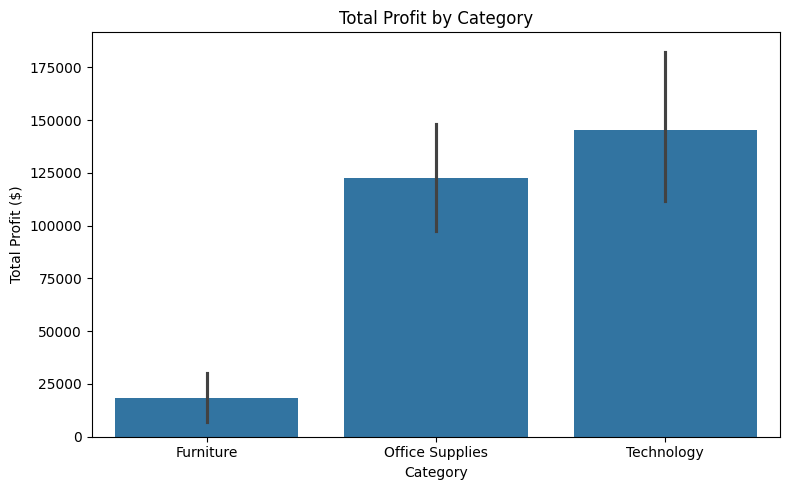

In [8]:
# Visualize profit by category
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Category", y="Profit", estimator=sum)
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()

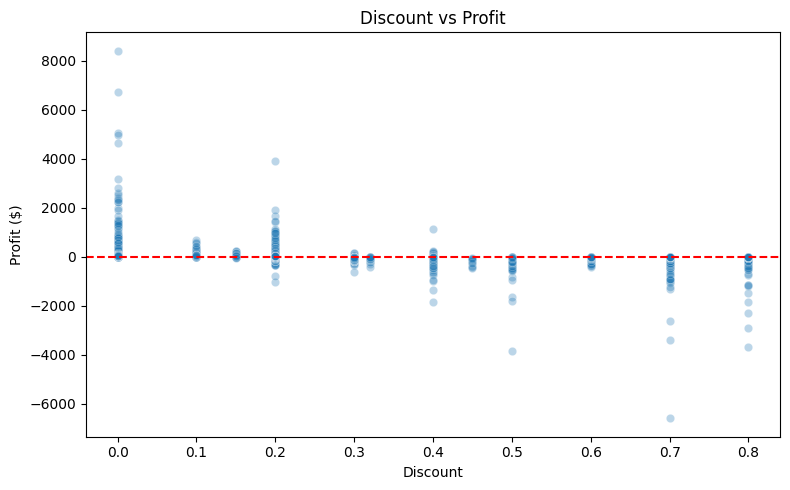

In [9]:
# Does higher discount = lower profit?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.3)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.axhline(y=0, color="red", linestyle="--")
plt.tight_layout()
plt.show()